In [1]:
# Практика 7. Візуалізація
# Коць Артем, ІТ-42
# Варіант 9 — Суми

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

city = "Суми"
base_sales = 31
base_temperature = -1

np.random.seed(9)

days = np.arange(1, 31)

# Кожен 6-й і 7-й день тижня вважаємо вихідним
weekend = np.isin(days % 7, [6, 0])

# Температура: базова температура ± приблизно 3°C
temperature = np.round(
    base_temperature + np.random.uniform(-3, 3, size=30),
    1
)

# Випадкова варіація продажів
random_variation = np.random.randint(-5, 6, size=30)

# У вихідні продажі на 15–25% вищі
weekend_bonus = np.where(
    weekend,
    np.random.uniform(1.15, 1.25, size=30),
    1
)

sales = np.round(
    (base_sales + random_variation) * weekend_bonus
).astype(int)

kiosk = pd.DataFrame({
    "день": days,
    "вихідний": weekend,
    "температура": temperature,
    "продажі": sales
})

kiosk

,день,вихідний,температура,продажі
0,1,False,-3.9,32
1,2,False,-1.0,32
2,3,False,-1.0,28
3,4,False,-3.2,34
4,5,False,-3.1,30
5,6,True,-2.7,38
6,7,True,-1.5,34
7,8,False,-2.5,30
8,9,False,-3.5,36
9,10,False,-1.9,26


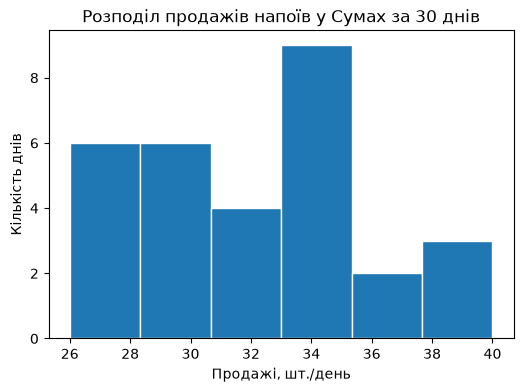

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(kiosk["продажі"], bins=6, edgecolor="white")

ax.set_xlabel("Продажі, шт./день")
ax.set_ylabel("Кількість днів")
ax.set_title("Розподіл продажів напоїв у Сумах за 30 днів")

plt.show()

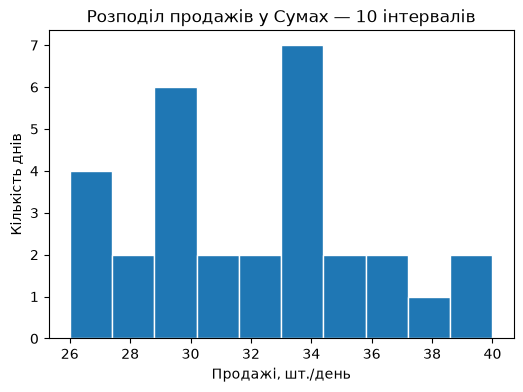

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(kiosk["продажі"], bins=10, edgecolor="white")

ax.set_xlabel("Продажі, шт./день")
ax.set_ylabel("Кількість днів")
ax.set_title("Розподіл продажів у Сумах — 10 інтервалів")

plt.show()

### Завдання 2. Порівняння bins

Було побудовано дві гістограми з `bins=6` та `bins=10`.

Для набору з 30 значень більш змістовною є гістограма з `bins=6`,
оскільки вона показує загальну структуру розподілу продажів без
надмірного поділу даних на маленькі інтервали.

Варіант з `bins=10` дає детальніше представлення, але через невелику
кількість спостережень деякі інтервали містять дуже мало значень.
Тому для загального аналізу розподілу продажів доцільніше
використовувати 6 інтервалів.

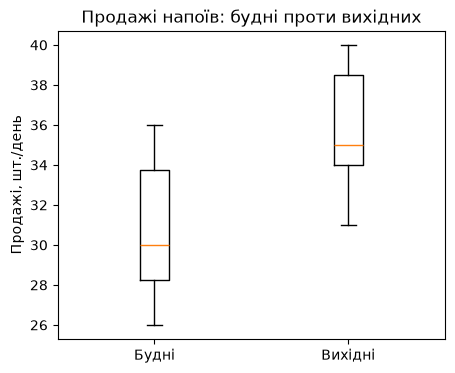

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))

weekday_sales = kiosk.loc[~kiosk["вихідний"], "продажі"]
weekend_sales = kiosk.loc[kiosk["вихідний"], "продажі"]

groups = [weekday_sales, weekend_sales]

ax.boxplot(
    groups,
    tick_labels=["Будні", "Вихідні"]
)

ax.set_ylabel("Продажі, шт./день")
ax.set_title("Продажі напоїв: будні проти вихідних")

plt.show()

### Завдання 3. Аналіз boxplot

На boxplot видно різницю між продажами у будні та вихідні дні.

У вихідні медіана продажів є вищою, ніж у будні. Це відповідає
умові Завдання 1, де для вихідних було задано збільшення продажів
приблизно на 15–25%.

Розкид значень також можна порівняти за висотою ящиків та довжиною
"вусів". Загалом вихідні мають вищий рівень продажів, тому їхній
boxplot розташований вище відносно будніх днів.

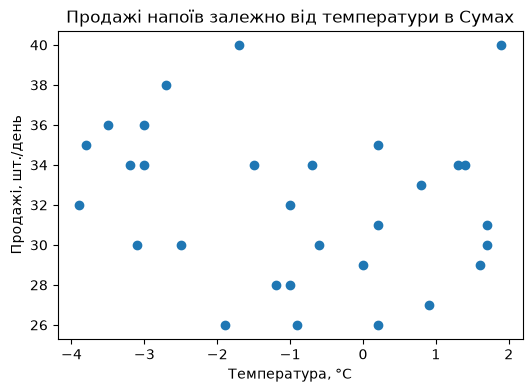

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    kiosk["температура"],
    kiosk["продажі"]
)

ax.set_xlabel("Температура, °C")
ax.set_ylabel("Продажі, шт./день")
ax.set_title("Продажі напоїв залежно від температури в Сумах")

plt.show()

### Завдання 4. Аналіз діаграми розсіювання

На графіку показано залежність кількості продажів від температури.

У створеному синтетичному наборі немає ідеально вираженого лінійного
зв'язку, оскільки на продажі також впливають випадкова варіація та
підвищення продажів у вихідні дні.

Загалом за вищої температури можна очікувати збільшення продажів
холодних напоїв. Для даних Сум це є логічним припущенням, хоча
в конкретному наборі зв'язок частково маскується випадковими
коливаннями.

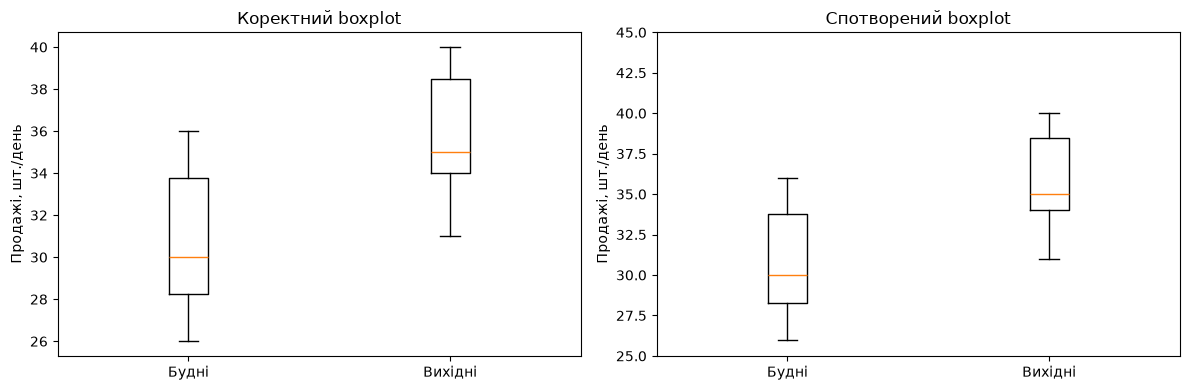

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Коректний boxplot
axes[0].boxplot(
    [weekday_sales, weekend_sales],
    tick_labels=["Будні", "Вихідні"]
)
axes[0].set_ylabel("Продажі, шт./день")
axes[0].set_title("Коректний boxplot")

# Спотворений boxplot
axes[1].boxplot(
    [weekday_sales, weekend_sales],
    tick_labels=["Будні", "Вихідні"]
)
axes[1].set_ylabel("Продажі, шт./день")
axes[1].set_title("Спотворений boxplot")

# Обрізаємо вісь Y
axes[1].set_ylim(25, 45)

plt.tight_layout()
plt.show()

### Завдання 5. Навмисно спотворений графік

У правому графіку було навмисно обрізано вісь Y до діапазону
25–45 шт./день.

Це приклад спотворення масштабу графіка. Оскільки вісь Y не
показує повний діапазон значень, різниця між буднями та вихідними
візуально виглядає більшою, ніж вона є насправді.

Числові значення даних при цьому не змінюються. Змінюється лише
масштаб візуального представлення, через що глядач може перебільшити
реальну різницю між двома групами.

Лівий графік є коректним, а правий демонструє, як зміна масштабу
може спотворювати сприйняття даних.

## Контрольні питання

### 1. Чому обрізана вісь Y на стовпчиковій діаграмі перебільшує різницю?

Обрізана вісь Y змінює візуальний масштаб графіка. Якщо вісь
починається не з нуля, невелика числова різниця може виглядати
як значна різниця у висоті стовпців. Самі числові значення
залишаються правильними, але графічне сприйняття стає оманливим.

### 2. Коли лінійний графік буде методологічною помилкою?

Лінійний графік може бути помилкою для категоріальних даних,
наприклад для порівняння продажів різних видів напоїв: "кава",
"чай", "сік". З'єднання таких категорій лінією створює враження,
що між ними існує безперервний порядок.

Для категоріальних даних доцільніше використовувати стовпчикову
діаграму. Лінійний графік доречніший для даних, де є природний
порядок або безперервна шкала, наприклад час.

### 3. Чому підписи осей, одиниці вимірювання і заголовок є частиною твердження графіка?

Без підписів незрозуміло, що саме вимірюється і в яких одиницях.
Заголовок пояснює, які дані та залежність показує графік.

Тому підписи осей, одиниці вимірювання і заголовок є не просто
оформленням, а важливою частиною правильної інтерпретації графіка.

### 4. Що таке chartjunk і чому він шкодить?

Chartjunk — це зайві декоративні елементи графіка, які не допомагають
аналізувати дані. Наприклад, непотрібний 3D-ефект на звичайній
стовпчиковій діаграмі може спотворювати сприйняття висоти стовпців.

Через chartjunk графік стає складнішим для читання, а увага
переміщується з даних на декоративні елементи. Тому для аналізу
краще використовувати просту та зрозумілу візуалізацію.